## Fig 3H Heatmap

In [1]:
suppressPackageStartupMessages({
  require(data.table)
  require(ggplot2)
  require(dplyr)
  require(tidyr)
  require(parallel)
  require(pheatmap)
  library(circlize)
  require(ComplexHeatmap)
})

In [2]:
plasma <- readRDS("../../data/figure-inputs/olink/MM_Plasma_Olink_Final.rds")
plasma_healthy_comparisons <- fread("../../data/figure-inputs/olink/plasma_longitudinal_comparisons_to_healthy.csv")

### First split the healthy subjects
healthy <- plasma[plasma$cohort.cohortGuid %in% c("BR1", "BR2")]

### then extract only Flu Year 1 day 0 samples
healthy <- healthy[sample.visitDetails == "Flu_Y1D0"]
unique_samples_boolean <- length(unique(healthy$subject.subjectGuid)) == length(unique(healthy$sample.sampleKitGuid))
print(paste("The # of unique subjects and unique samples is equal:", unique_samples_boolean))

mm_treatment <- plasma[sample.visitDetails %in% c("PreTx", "PI2C", "EI", "ASCT60d", "ASCT1y", "ASCT2y")]

healthy$Cohort <- "Healthy"
mm_treatment$Cohort <- "NDMM"
plasma_treatment <- rbind(healthy, mm_treatment)
plasma_treatment[plasma_treatment$sample.visitDetails == "Flu_Y1D0"]$sample.visitDetails <- "Healthy"

[1] "The # of unique subjects and unique samples is equal: TRUE"


In [3]:
# head(plasma_treatment)
data_matrix <- dcast(plasma_treatment,
  formula = olink.assay ~ sample.visitDetails, value.var = "olink.NPX_norm", fun.aggregate = function(x) median(x, na.rm = TRUE)
)

mat <- as.matrix(data_matrix[, -1])
mat <- apply(mat, 2, as.numeric)
rownames(mat) <- data_matrix$olink.assay
str(mat)

# DEPs: FDR < 0.05 and |log2FC| > 2 on NPX scale vs Healthy
deps <- unique(plasma_healthy_comparisons[adjP < 0.05 & abs(Log2FC) > 2]$Assay)
length(deps)

 num [1:1463, 1:7] 3.204 1.927 1.799 1.161 -0.016 ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:1463] "AARSD1" "ABHD14B" "ABL1" "ACAA1" ...
  ..$ : chr [1:7] "PreTx" "PI2C" "EI" "ASCT60d" ...


[1] 116

In [4]:
pdf("../../data/figure-outputs/figure-3/fig_3h.pdf", width = 35, height = 7)
heatmap <- Heatmap(
  scale(t(mat[rownames(mat) %in% deps, colnames(mat) != "ASCT2y"])),
  name = "Expression",
  cluster_rows = FALSE,
  cluster_columns = TRUE,
  show_row_names = TRUE,
  show_column_names = TRUE,
  show_column_dend = FALSE,
  column_title = "",
  column_title_gp = gpar(fontsize = 25, fontface = "bold"),
  row_names_gp = gpar(fontsize = 20),
  column_names_gp = gpar(fontsize = 20),
  rect_gp = gpar(col = "black", lwd = 0.75),
  col = colorRamp2(c(-2.5, 0, 2.5), c("navy", "white", "red4")),
  heatmap_legend_param = list(title = "Expression      ")
)
draw(heatmap)
dev.off()

pdf 
  2

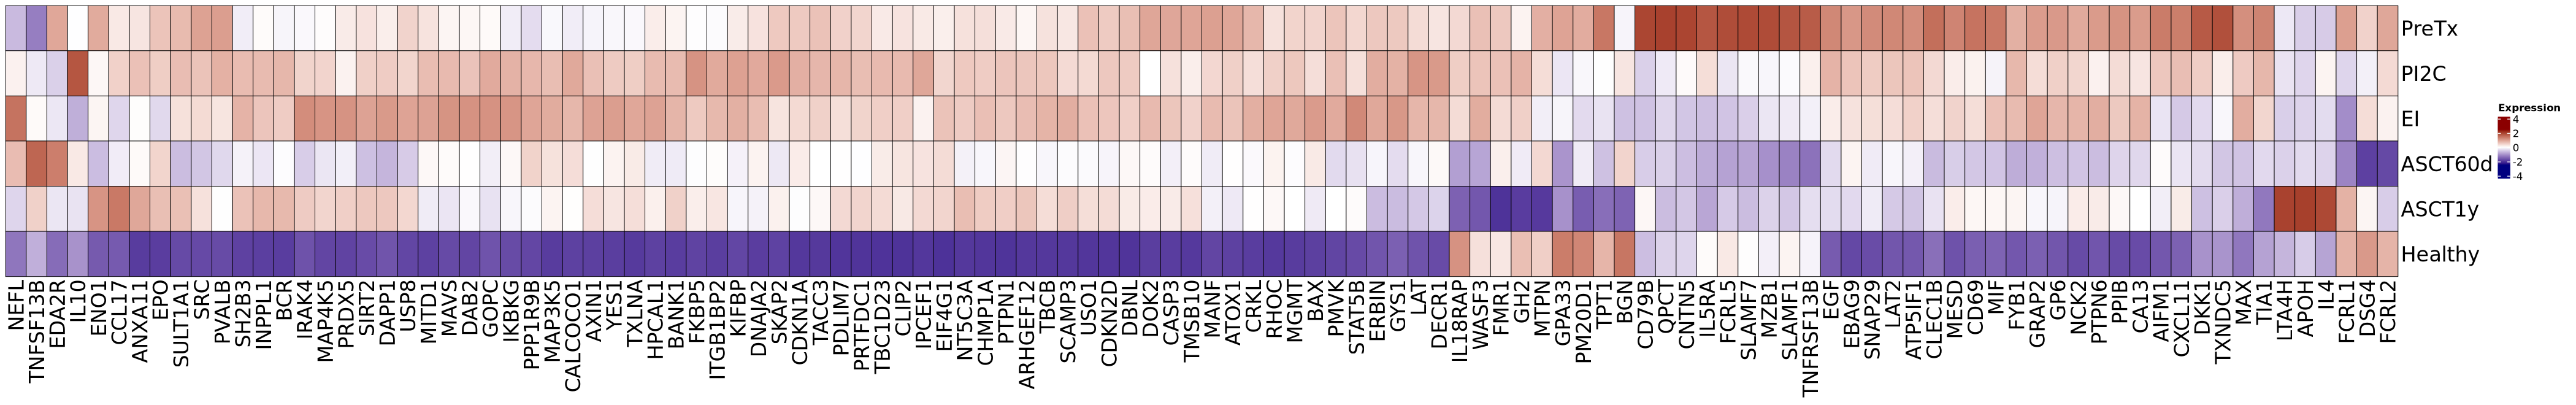

In [5]:
options(repr.plot.width = 35, repr.plot.height = 5.5)
heatmap